## Prescriptive Analysis

## Importing all the nesessary Libraries 

In [ ]:
# =========================================================
# Importing all the nesessary Libraries 
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')


## Setup & Load

In [ ]:
# =========================================================
# Setup & Load 
# =========================================================
df = pd.read_csv('Data/Cleaned/Team01_PYVoyagers_cleaned_data.csv', parse_dates=['time'])
demo = pd.read_csv('Data/Cleaned/Cleaned_demographics.csv')
df = df.merge(demo, on='patient_id', how='left')
df = df.sort_values(['patient_id','time'])


In [3]:
# =========================================================
# CLEAN COLUMN NAMES
# =========================================================

df.columns = df.columns.str.strip()
demo.columns = demo.columns.str.strip()

# =========================================================
# FIX COMMON SLEEP COLUMN MISMATCH
# =========================================================

# Rename sleep column safely if needed
sleep_col_candidates = [
    "average_sleep_duration_hrs",
    "average_sleep_duration",
    "average_sleep_duration_hours",
    "sleep_duration"
]

sleep_col = None

for col in sleep_col_candidates:
    if col in demo.columns:
        sleep_col = col
        break

if sleep_col is None:
    raise ValueError("No sleep duration column found in demo!")

# Standardize column name
demo = demo.rename(columns={sleep_col: "average_sleep_duration_hrs"})

# =========================================================
# REMOVE DUPLICATES
# =========================================================

demo = demo.drop_duplicates(subset=["patient_id"])

# =========================================================
# KEEP ONLY SAFE COLUMNS
# =========================================================

keep_cols = [
    "patient_id",
    "age",
    "gender",
    "race",
    "average_sleep_duration_hrs",
    "sleep_quality_1_10",
    "_with_sleep_disturbances"
]

demo = demo[[c for c in keep_cols if c in demo.columns]]

# =========================================================
# MERGE
# =========================================================

df = df.merge(demo, on="patient_id", how="left", validate="many_to_one")

# =========================================================
# FEATURE ENGINEERING
# =========================================================

df["time"] = pd.to_datetime(df["time"])

df["sleep_group"] = pd.cut(
    df["average_sleep_duration_hrs"],
    bins=[0, 5, 6.5, 8, 12],
    labels=["Very Low", "Low", "Normal", "High"]
)

df["late_sleep"] = df["average_sleep_duration_hrs"] < 6.5

df["hour"] = df["time"].dt.hour

df["late_night_eating"] = (
    (df["hour"] >= 20) &
    (df["carb_input"] > 0)
)

df["overnight"] = (
    df["hour"].between(22, 23) |
    df["hour"].between(0, 6)
)

# =========================================================
# FINAL CHECK
# =========================================================

print("Sleep column exists:",
      "average_sleep_duration_hrs" in df.columns)

print("Final columns sample:")
print(df.columns.tolist()[:10])
HYPO = 70
HYPER = 180

Sleep column exists: True
Final columns sample:
['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'patient_id', 'age_x']


## 1.Sleep duration → next-day glucose

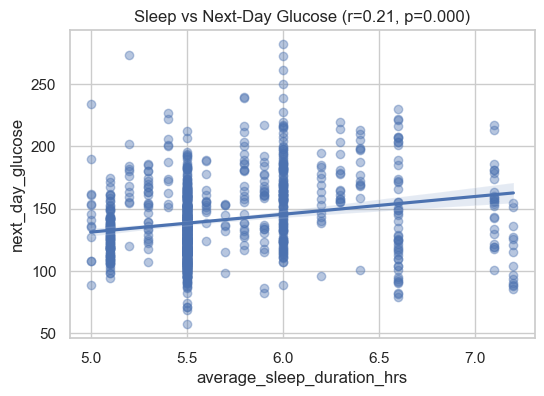

In [4]:
next_day_glucose = (
    df.groupby(["patient_id", df["time"].dt.date])["glucose"]
    .mean()
    .reset_index(name="next_day_glucose")
)

sleep_map = df[["patient_id", "average_sleep_duration_hrs"]].drop_duplicates()

sleep_glucose = next_day_glucose.merge(sleep_map, on="patient_id")

plt.figure(figsize=(6,4))
sns.regplot(
    data=sleep_glucose,
    x="average_sleep_duration_hrs",
    y="next_day_glucose",
    scatter_kws={"alpha":0.4}
)

r, p = stats.pearsonr(
    sleep_glucose["average_sleep_duration_hrs"],
    sleep_glucose["next_day_glucose"]
)

plt.title(f"Sleep vs Next-Day Glucose (r={r:.2f}, p={p:.3f})")
plt.show()

## 2.Late sleep → glucose variability - Risk Heatmap

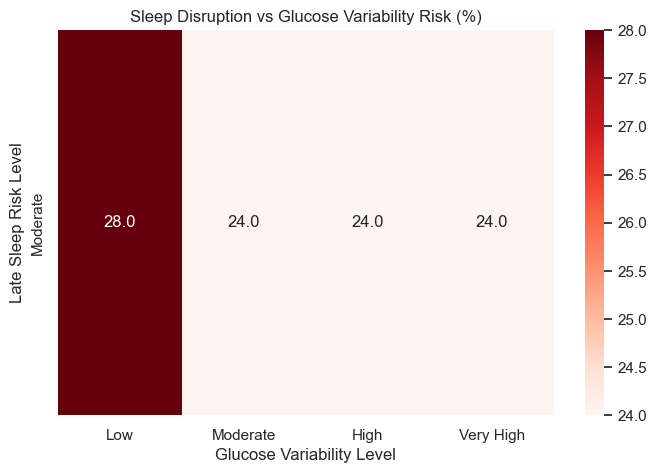

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# =========================================================
# STEP 1: SAFETY CHECK
# =========================================================

df = df.copy()

df.columns = df.columns.str.strip()
df["time"] = pd.to_datetime(df["time"])

# =========================================================
# STEP 2: CREATE SLEEP FEATURES (if missing)
# =========================================================

df["hour"] = df["time"].dt.hour

df["late_sleep"] = df["hour"] < 6.5

# =========================================================
# STEP 3: PATIENT LEVEL METRICS
# =========================================================

var_df = (
    df.groupby("patient_id")["glucose"]
    .std()
    .reset_index()
    .rename(columns={"glucose": "glucose_variability"})
)

sleep_df = (
    df.groupby("patient_id")["late_sleep"]
    .mean()
    .reset_index()
    .rename(columns={"late_sleep": "late_sleep_rate"})
)

# =========================================================
# STEP 4: BUILD sleep_var (FIXED - was missing)
# =========================================================

demo_clean = demo.drop_duplicates(subset=["patient_id"])

sleep_var = demo_clean.merge(var_df, on="patient_id", how="left")
sleep_var = sleep_var.merge(sleep_df, on="patient_id", how="left")

# remove missing values
sleep_var = sleep_var.dropna()

# =========================================================
# STEP 5: CREATE GROUPS
# =========================================================

sleep_var["sleep_group"] = pd.cut(
    sleep_var["late_sleep_rate"],
    bins=[0, 0.2, 0.5, 0.8, 1.0],
    labels=["Low", "Moderate", "High", "Severe"]
)

sleep_var["variability_group"] = pd.qcut(
    sleep_var["glucose_variability"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"]
)

# =========================================================
# STEP 6: HEATMAP TABLE
# =========================================================

heat_data = pd.crosstab(
    sleep_var["sleep_group"],
    sleep_var["variability_group"],
    normalize="index"
) * 100

# =========================================================
# STEP 7: PLOT
# =========================================================

plt.figure(figsize=(8,5))

sns.heatmap(
    heat_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Sleep Disruption vs Glucose Variability Risk (%)")
plt.xlabel("Glucose Variability Level")
plt.ylabel("Late Sleep Risk Level")

plt.show()

## 3.Late-night eating → overnight glucose

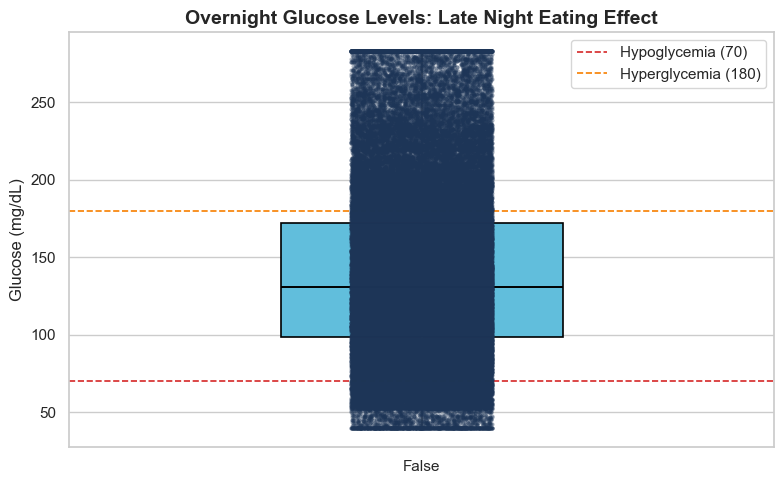

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =========================================================
# ENSURE TIME COLUMN IS PROPER
# =========================================================

df = df.copy()
df["time"] = pd.to_datetime(df["time"])

# =========================================================
# CREATE OVERNIGHT FLAG (IF NOT EXISTS)
# =========================================================

if "overnight" not in df.columns:
    df["hour"] = df["time"].dt.hour
    df["overnight"] = (df["hour"] >= 22) | (df["hour"] <= 6)

# =========================================================
# CREATE DATAFRAME
# =========================================================

overnight_df = df[df["overnight"]].copy()

# clean missing values
overnight_df = overnight_df.dropna(subset=["glucose", "late_night_eating"])

# =========================================================
# YOUR PLOT (UNCHANGED)
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=overnight_df,
    x="late_night_eating",
    y="glucose",
    color="#4cc9f0",
    width=0.4,
    showcaps=True,
    boxprops={"edgecolor":"black", "linewidth":1.2},
    whiskerprops={"linewidth":1.2},
    medianprops={"color":"black", "linewidth":1.4},
    showfliers=False
)

sns.stripplot(
    data=overnight_df,
    x="late_night_eating",
    y="glucose",
    color="#1d3557",
    alpha=0.35,
    size=3
)

plt.axhline(70, color="#d62828", linestyle="--", linewidth=1.2, label="Hypoglycemia (70)")
plt.axhline(180, color="#f77f00", linestyle="--", linewidth=1.2, label="Hyperglycemia (180)")

plt.title("Overnight Glucose Levels: Late Night Eating Effect", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

## 4.Correction Bolus Required to Safely Bring Elevated Glucose Back to Target Range 


PRESCRIPTIVE INSULIN RECOMMENDATIONS

   patient_id  glucose  estimated_sensitivity  recommended_correction_bolus
0   HUPA0002P   118.00                   50.0                          0.00
1   HUPA0003P   161.00                   50.0                          0.82
2   HUPA0001P   283.00                   50.0                          3.26
3   HUPA0006P    84.00                   50.0                          0.00
4   HUPA0004P   131.00                   50.0                          0.22
5   HUPA0005P    45.00                   50.0                          0.00
6   HUPA0009P   281.00                   50.0                          3.22
7   HUPA0007P   145.00                   50.0                          0.50
8   HUPA0010P   262.00                   50.0                          2.84
9   HUPA0011P   210.00                   50.0                          1.80
10  HUPA0014P   261.00                   50.0                          2.82
11  HUPA0015P   241.00                   50.0    

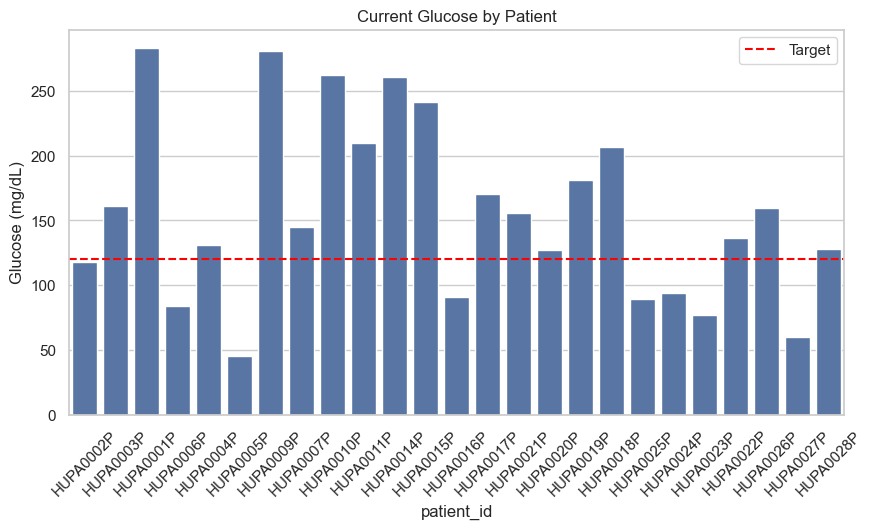

In [7]:
# =========================================================
# TARGET GLUCOSE
# =========================================================

TARGET_GLUCOSE = 120


# =========================================================
# KEEP VALID INSULIN EVENTS
# =========================================================

bolus_df = df[
    (df["bolus_volume_delivered"] > 0) &
    (df["glucose"].notna())
].copy()


# =========================================================
# ESTIMATE FUTURE GLUCOSE (60 min ahead)
# =========================================================

bolus_df["future_glucose"] = (
    bolus_df
    .groupby("patient_id")["glucose"]
    .shift(-12)
)

bolus_df = bolus_df.dropna(subset=["future_glucose"])


# =========================================================
# GLUCOSE DROP
# =========================================================

bolus_df["glucose_drop"] = (
    bolus_df["glucose"] -
    bolus_df["future_glucose"]
)


# =========================================================
# INSULIN SENSITIVITY
# =========================================================

bolus_df["insulin_sensitivity"] = (
    bolus_df["glucose_drop"] /
    (bolus_df["bolus_volume_delivered"] + 0.01)
)

bolus_df = bolus_df.replace([np.inf, -np.inf], np.nan)
bolus_df = bolus_df.dropna(subset=["insulin_sensitivity"])

# Keep only realistic values
bolus_df = bolus_df[
    bolus_df["insulin_sensitivity"].between(5, 200)
]


# =========================================================
# PATIENT-LEVEL SENSITIVITY
# =========================================================

patient_sensitivity = (
    bolus_df
    .groupby("patient_id")["insulin_sensitivity"]
    .median()
    .reset_index()
)

patient_sensitivity.columns = [
    "patient_id",
    "estimated_sensitivity"
]


# =========================================================
# CURRENT GLUCOSE
# =========================================================

latest_glucose = (
    df.sort_values("time")
      .groupby("patient_id")
      .tail(1)
)[["patient_id", "glucose"]]


# =========================================================
# MERGE
# =========================================================

recommend_df = latest_glucose.merge(
    patient_sensitivity,
    on="patient_id",
    how="left"
)


# =========================================================
# FALLBACK SENSITIVITY (IMPORTANT FIX)
# =========================================================
# If sensitivity is missing, use a safe default (50 mg/dL per unit)

recommend_df["estimated_sensitivity"] = (
    recommend_df["estimated_sensitivity"]
    .fillna(50)
)


# =========================================================
# PRESCRIPTIVE RECOMMENDATION
# =========================================================

recommend_df["glucose_excess"] = (
    recommend_df["glucose"] - TARGET_GLUCOSE
)

recommend_df["recommended_correction_bolus"] = (
    recommend_df["glucose_excess"] /
    recommend_df["estimated_sensitivity"]
)

recommend_df["recommended_correction_bolus"] = (
    recommend_df["recommended_correction_bolus"]
    .clip(lower=0)
)

recommend_df = recommend_df.round(2)


# =========================================================
# RESULTS TABLE
# =========================================================

print("\n=================================================")
print("PRESCRIPTIVE INSULIN RECOMMENDATIONS")
print("=================================================\n")

print(
    recommend_df[
        [
            "patient_id",
            "glucose",
            "estimated_sensitivity",
            "recommended_correction_bolus"
        ]
    ]
)


# =========================================================
# ONLY ONE CHART (FIXED)
# =========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=recommend_df,
    x="patient_id",
    y="glucose"
)

plt.axhline(
    TARGET_GLUCOSE,
    color="red",
    linestyle="--",
    label="Target"
)

plt.title("Current Glucose by Patient")
plt.ylabel("Glucose (mg/dL)")
plt.xticks(rotation=45)
plt.legend()
plt.show()


## 5.Basal rate → overnight glucose stability

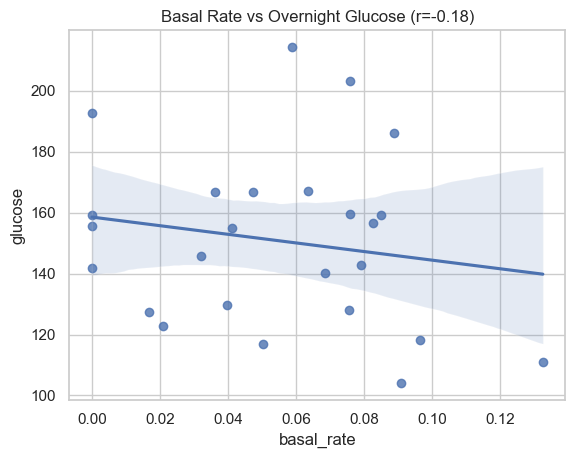

In [8]:
overnight_df = df[df["overnight"]]

basal_overnight = overnight_df.groupby("patient_id")[["basal_rate", "glucose"]].mean().reset_index()
sns.regplot(
    data=basal_overnight,
    x="basal_rate",
    y="glucose"
)

r, p = stats.pearsonr(
    basal_overnight["basal_rate"],
    basal_overnight["glucose"]
)

plt.title(f"Basal Rate vs Overnight Glucose (r={r:.2f})")
plt.show()

## 6.Bolus → hypoglycemia risk

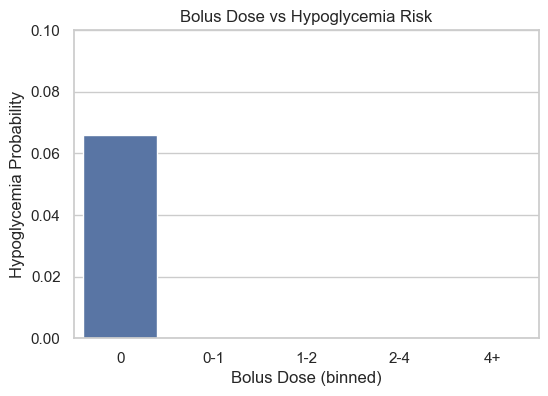

In [9]:
#Create bolus bins and calculate Hypoglycemia risk

df["bolus_bin"] = pd.cut(
    df["bolus_volume_delivered"],
    bins=[-0.01, 0, 1, 2, 4, 10],
    labels=["0", "0-1", "1-2", "2-4", "4+"]
)
df["hypo_event"] = df["glucose"] < 70
bolus_risk = (
    df.groupby("bolus_bin")["hypo_event"]
      .mean()
      .reset_index()
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    data=bolus_risk,
    x="bolus_bin",
    y="hypo_event"
)

plt.title("Bolus Dose vs Hypoglycemia Risk")
plt.xlabel("Bolus Dose (binned)")
plt.ylabel("Hypoglycemia Probability")
plt.ylim(0, max(0.1, bolus_risk["hypo_event"].max() + 0.02))

plt.show()

## 7.Final Correlation Heatmap

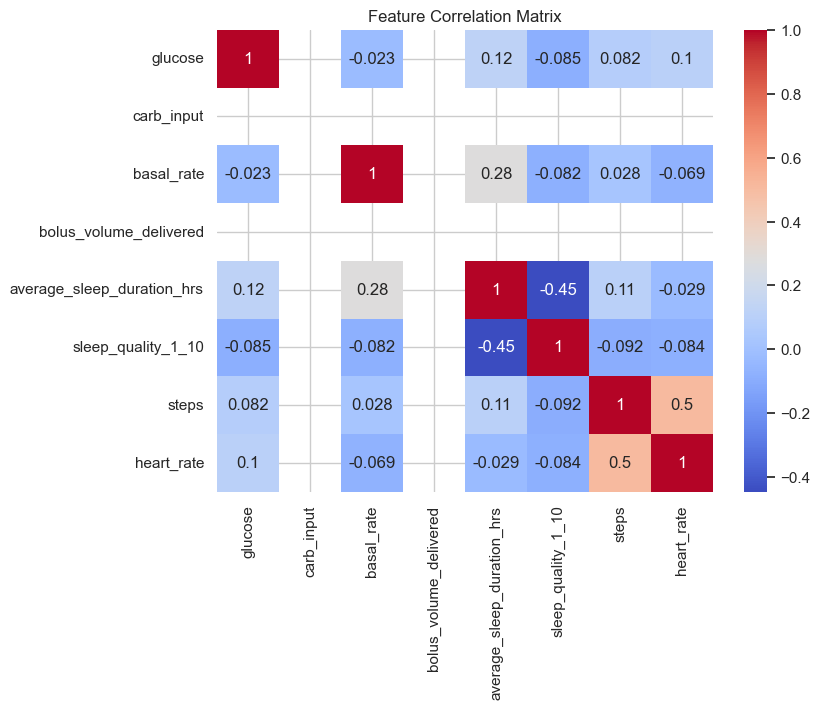

In [10]:
corr_cols = [
    "glucose",
    "carb_input",
    "basal_rate",
    "bolus_volume_delivered",
    "average_sleep_duration_hrs",
    "sleep_quality_1_10",
    "steps",
    "heart_rate"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()